# 03. Regularized Linear Models

**Goal:** Train models on the massive Bigram sparse matrix. We will use L2 Regularization (Ridge / Logistic Regression) to prevent overfitting on this massive feature space.

In [1]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
import joblib
import sys
sys.path.append('../../../shared')
from evaluation_utils import evaluate_classification

## 1. Load Bigram Data

In [2]:
X_train, X_test, y_train, y_test, vectorizer = joblib.load('../data/processed/bigram_data.pkl')

> **📌 Decision Note — Why Model Selection for Massive Sparsity?**
>
> **Chosen approach:** Logistic Regression and Ridge Classifier (L2 Regularization)
>
> **Why this works:** With >100,000 features, models easily memorize the training data. L2 regularization drastically penalizes large coefficients, forcing the model to rely on truly generalizable sentiment indicators.
>
> **Alternatives we could have used:**
> | Option | Pros | Cons |
> |--------|------|------|
> | Standard SVM / Unregularized LR | Standard models | Will heavily overfit the training data due to the curse of dimensionality. |
> | Decision Trees / Random Forest | Handles non-linear | Performs terribly and is extremely slow on 100k+ sparse features. |
>
> **Why we chose this over alternatives:** Linear models with strong L2 regularization are incredibly fast and effective on massive N-gram matrices.

## 2. Multinomial Naive Bayes (Baseline)

Accuracy: 0.8807

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      5055
           1       0.89      0.87      0.88      4945

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



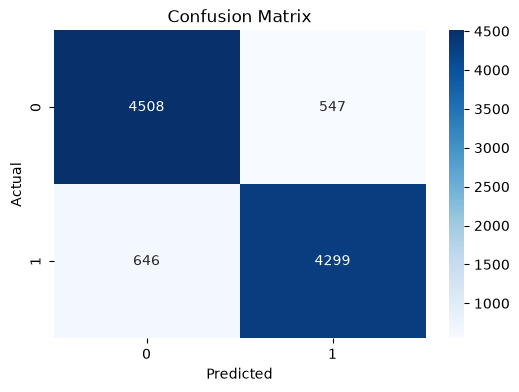

['../models/multinomial_nb.pkl']

In [3]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
evaluate_classification(y_test, y_pred_nb)
joblib.dump(nb, '../models/multinomial_nb.pkl')

## 3. Logistic Regression (L2 Penalty)

Accuracy: 0.9026

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      5055
           1       0.90      0.91      0.90      4945

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



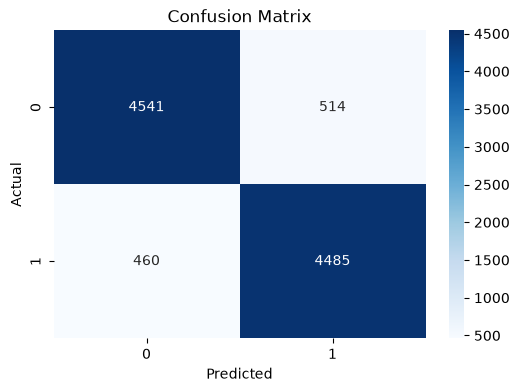

['../models/logistic_regression_l2.pkl']

In [4]:
lr = LogisticRegression(max_iter=1000, C=0.5) # C=0.5 increases regularization
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_classification(y_test, y_pred_lr)
joblib.dump(lr, '../models/logistic_regression_l2.pkl')

## 4. Ridge Classifier

Accuracy: 0.847

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      5055
           1       0.84      0.85      0.85      4945

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



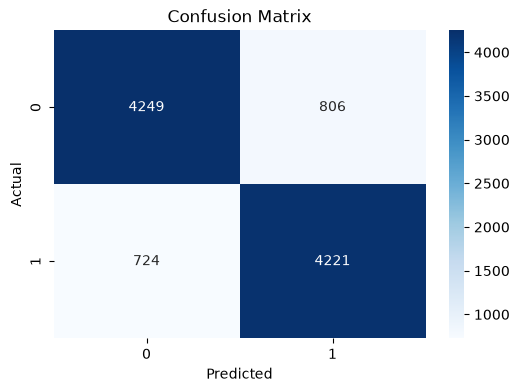

['../models/ridge_classifier.pkl']

In [5]:
ridge = RidgeClassifier(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
evaluate_classification(y_test, y_pred_ridge)
joblib.dump(ridge, '../models/ridge_classifier.pkl')

## Key Takeaways
- [x] Bigrams allow us to catch negations, bumping accuracy nicely.
- [x] L2 regularized linear models (Logistic/Ridge) excel in high dimensional spaces where $p > n$ or $p \approx n$.